# Deep learning practice

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


import pandas as pd

In [ ]:
# Load Dataset

df = pd.read_csv("dataset_practical_session.csv")
y=df["PK"]
x=df.drop("PK", axis=1)

X_tensor = torch.tensor(x.values, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.long)

### Normalize data

#scaler=StandarScaler() ..... 
### Split train test data


In [20]:
def do_model(size_layer):

    model=nn.Sequential(
    nn.Linear(6,size_layer),
    nn.ReLU(),
    nn.Linear(size_layer,2)
    )
    return model

In [21]:
model=do_model(16)
learning_rate = 0.01
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [22]:
for epoch in range(100):
    # Forward
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)

    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/100], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.4296
Epoch [20/100], Loss: 0.3556
Epoch [30/100], Loss: 0.2985
Epoch [40/100], Loss: 0.2516
Epoch [50/100], Loss: 0.2013
Epoch [60/100], Loss: 0.1437
Epoch [70/100], Loss: 0.1224
Epoch [80/100], Loss: 0.1120
Epoch [90/100], Loss: 0.1083
Epoch [100/100], Loss: 0.1038


In [25]:
param_grid = {
    "hidden_size": [16, 32, 64],
    "learning_rate": [0.01, 0.001],
    "epochs": [50, 100],
    "optimizer": ["Adam", "SGD", "RMSprop"]
}

results = []

for hidden_size in param_grid["hidden_size"]:
    for lr in param_grid["learning_rate"]:
        for n_epochs in param_grid["epochs"]:
            for opt_name in param_grid["optimizer"]:
            
                # DO model and loss function
                model = do_model(hidden_size)
                criterion = nn.CrossEntropyLoss()

                if opt_name == "Adam":
                    optimizer = optim.Adam(model.parameters(), lr=lr)
                elif opt_name == "SGD":
                    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
                elif opt_name == "RMSprop":
                    optimizer = optim.RMSprop(model.parameters(), lr=lr)

                # Training
                for epoch in range(n_epochs):
                    outputs = model(X_tensor)
                    loss = criterion(outputs, y_tensor)

                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()

                    if (epoch+1) % 10 == 0:
                        print(f'Epoch [{epoch+1}/100], Loss: {loss.item():.4f}')

                # Evaluate accuracy
                with torch.no_grad():
                    preds = torch.argmax(model(X_tensor), dim=1)
                    acc = (preds == y_tensor).float().mean().item()

                # Save results
                results.append({
                    "hidden_size": hidden_size,
                    "learning_rate": lr,
                    "epochs": n_epochs,
                    "optimizer": opt_name,
                    "final_loss": loss.item(),
                    "accuracy": acc
                })
                print("Results have been saved!")

# Show
df_results = pd.DataFrame(results)
print(df_results)

Epoch [10/100], Loss: 0.7334
Epoch [20/100], Loss: 0.5167
Epoch [30/100], Loss: 0.3550
Epoch [40/100], Loss: 0.3113
Epoch [50/100], Loss: 0.2637
Results have been saved!
Epoch [10/100], Loss: 0.5362
Epoch [20/100], Loss: 0.4514
Epoch [30/100], Loss: 0.4264
Epoch [40/100], Loss: 0.4097
Epoch [50/100], Loss: 0.4043
Results have been saved!
Epoch [10/100], Loss: 0.6344
Epoch [20/100], Loss: 0.4366
Epoch [30/100], Loss: 0.4617
Epoch [40/100], Loss: 0.4744
Epoch [50/100], Loss: 0.4259
Results have been saved!
Epoch [10/100], Loss: 1.0990
Epoch [20/100], Loss: 0.6644
Epoch [30/100], Loss: 0.4297
Epoch [40/100], Loss: 0.3533
Epoch [50/100], Loss: 0.2872
Epoch [60/100], Loss: 0.2275
Epoch [70/100], Loss: 0.1921
Epoch [80/100], Loss: 0.1639
Epoch [90/100], Loss: 0.1431
Epoch [100/100], Loss: 0.1293
Results have been saved!
Epoch [10/100], Loss: 0.6276
Epoch [20/100], Loss: 0.4301
Epoch [30/100], Loss: 0.4181
Epoch [40/100], Loss: 0.3930
Epoch [50/100], Loss: 0.3832
Epoch [60/100], Loss: 0.3728


In [4]:
df_results

,Unnamed: 0,hidden_size,learning_rate,epochs,optimizer,final_loss,accuracy
0,0,16,0.010,50,Adam,0.263690,0.893180
1,1,16,0.010,50,SGD,0.404334,0.808951
2,2,16,0.010,50,RMSprop,0.425917,0.842426
3,3,16,0.010,100,Adam,0.129267,0.956176
4,4,16,0.010,100,SGD,0.301457,0.868166
5,5,16,0.010,100,RMSprop,0.224063,0.909117
6,6,16,0.001,50,Adam,0.419116,0.805277
7,7,16,0.001,50,SGD,0.426362,0.809348
8,8,16,0.001,50,RMSprop,0.367632,0.836865
9,9,16,0.001,100,Adam,0.347152,0.843152


## Question 1

- Try different number of neurons / number of hidden layers. How does these hyperparameter influence the learning?

**Response**:
- In this case we can see how the # of neurons changes the range between the less accurate and the most accurate configuration. But we can see with more neurons the best accuracy is lower because the system is overfited because the system isn't too complex. The best configuration is wich there are less neurons

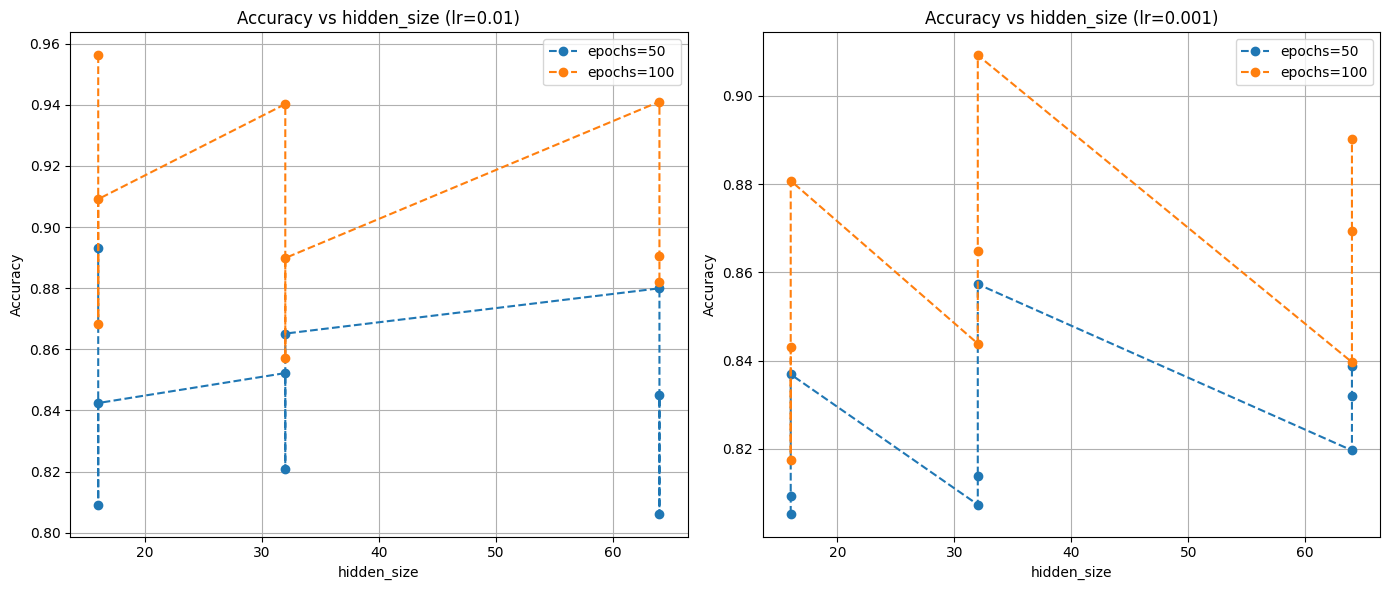

In [29]:
plt.figure(figsize=(14, 6))

for i, lr in enumerate(df_results["learning_rate"].unique()):
    plt.subplot(1, len(df_results["learning_rate"].unique()), i+1)
    
    for n_epochs in df_results["epochs"].unique():
        subset = df_results[(df_results["learning_rate"] == lr) & 
                            (df_results["epochs"] == n_epochs)]
        
        plt.plot(subset["hidden_size"], subset["accuracy"], 
                 marker="o", linestyle="--", label=f"epochs={n_epochs}")
    
    plt.title(f"Accuracy vs hidden_size (lr={lr})")
    plt.xlabel("hidden_size")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

## Question 2

- Try different learning rates. How does this hyperparameter influence the learning? 

**Response**:

- In this case we can see how the learning rate change the difference between the accuracy in the same size of layer but in different optimizer, naturally, if we use a learning rate littler we must need to use more epochs of training. Same as before, in this case the problem isn't too complex so use a learning rate bigger will be better for computation cost and same(or as in this case more) precise.
---

## Question 3

- Try different optimizers. How does this hyperparameter influence the learning?

**Response**:

- It's intituive think that the best optimizer in this case is Adam, after this RMSprop and SGD at the end. As before we can see the range decrease too among the different optimizer, but as before, the problem isn't really complex to use neural networks so use the simplest is the best, in this case Adam

---

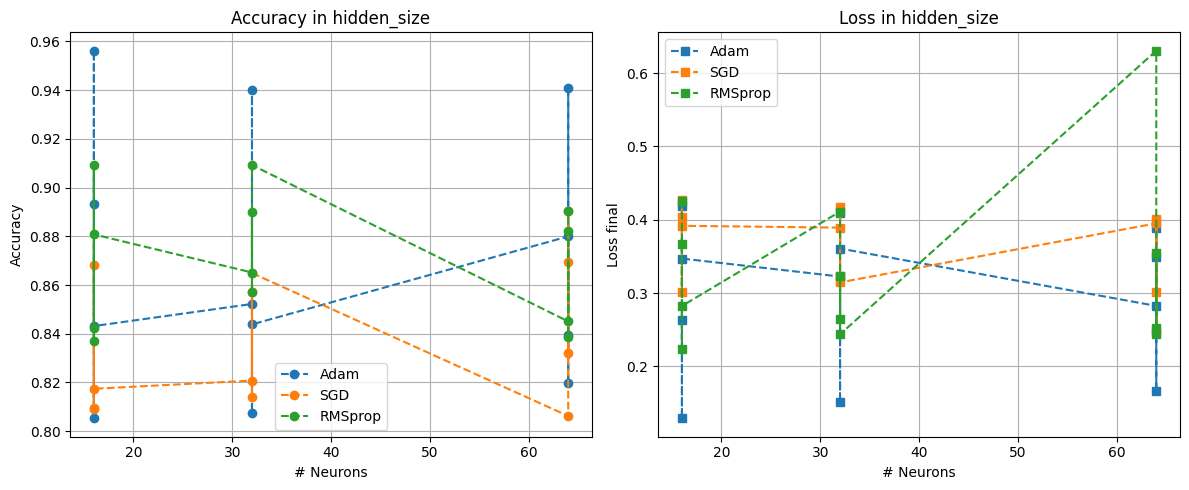

In [30]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for opt in df_results["optimizer"].unique():
    subset = df_results[df_results["optimizer"] == opt]
    plt.plot(subset["hidden_size"], subset["accuracy"], marker="o", linestyle="--", label=opt)

plt.title("Accuracy in hidden_size")
plt.xlabel("# Neurons")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for opt in df_results["optimizer"].unique():
    subset = df_results[df_results["optimizer"] == opt]
    plt.plot(subset["hidden_size"], subset["final_loss"], marker="s", linestyle="--", label=opt)

plt.title("Loss in hidden_size")
plt.xlabel("# Neurons")
plt.ylabel("Loss final")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## Question 4

- Which other hyper parameters could influence the learning? 

**Response**:

- The number of epochs is a hyperparameter crucial in NN training, so it will be one of the most important parameters.
- We can talk too of the loss function to use and the activation function of the neurons but, again, the problem isn't too complex to use neuronal networks, so at the end this canges will not impact in a significant way the results


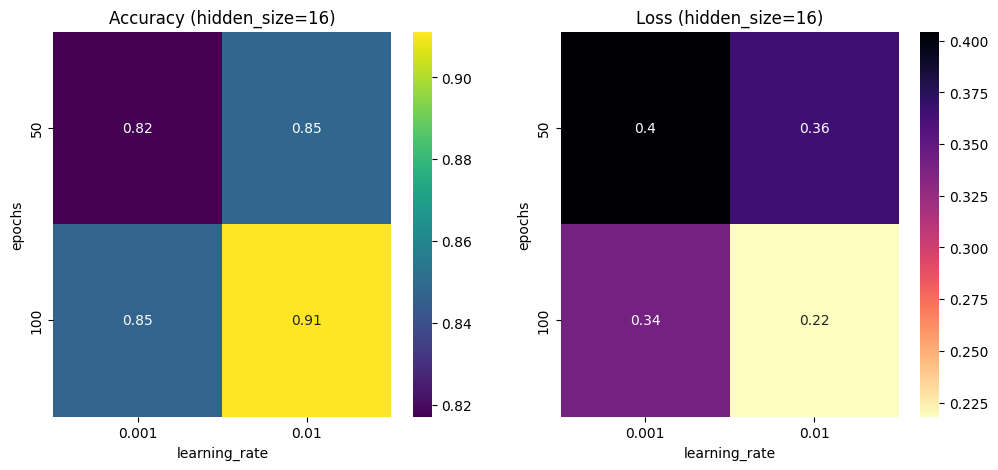

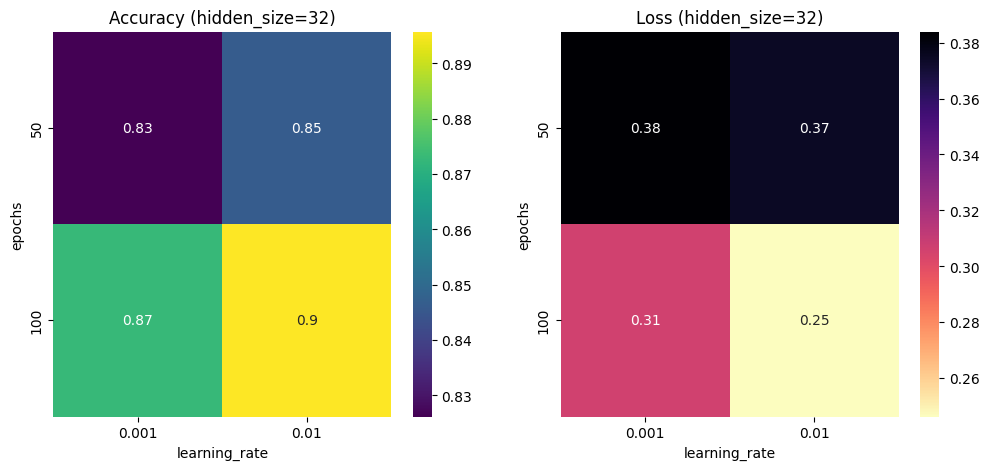

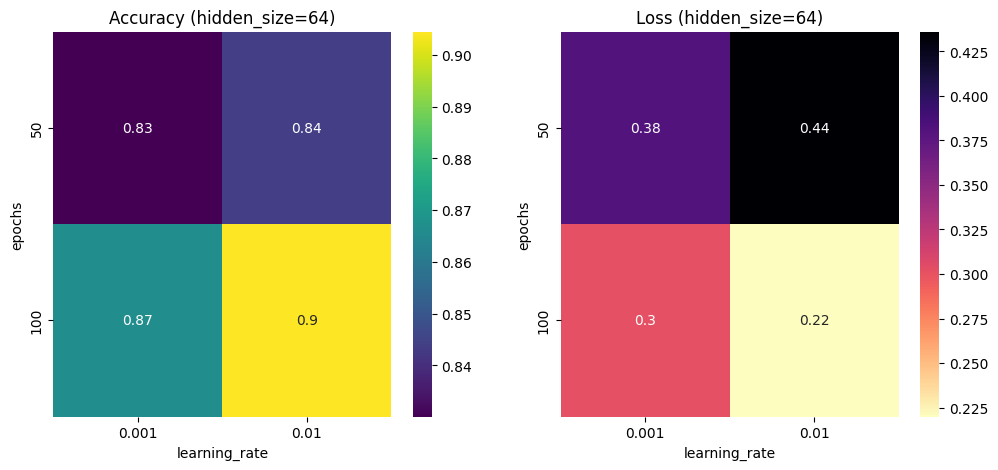

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

for h in df_results["hidden_size"].unique():
    subset = df_results[df_results["hidden_size"] == h]
    pivot_acc = subset.pivot_table(index="epochs", columns="learning_rate", values="accuracy")
    pivot_loss = subset.pivot_table(index="epochs", columns="learning_rate", values="final_loss")

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    sns.heatmap(pivot_acc, annot=True, cmap="viridis")
    plt.title(f"Accuracy (hidden_size={h})")
    
    plt.subplot(1,2,2)
    sns.heatmap(pivot_loss, annot=True, cmap="magma_r")
    plt.title(f"Loss (hidden_size={h})")
    
    plt.show()


## Question 5

- How precise is the prediction with a neural network compared to the other regression methods tested in TASK 2? What is the size of the neural network in memory? How fast is the inference?

In [ ]:
## Get best hyper parametres and calculate its size

df_results

,hidden_size,learning_rate,epochs,optimizer,final_loss,accuracy
0,16,0.010,50,Adam,0.263690,0.893180
1,16,0.010,50,SGD,0.404334,0.808951
2,16,0.010,50,RMSprop,0.425917,0.842426
3,16,0.010,100,Adam,0.129267,0.956176
4,16,0.010,100,SGD,0.301457,0.868166
5,16,0.010,100,RMSprop,0.224063,0.909117
6,16,0.001,50,Adam,0.419116,0.805277
7,16,0.001,50,SGD,0.426362,0.809348
8,16,0.001,50,RMSprop,0.367632,0.836865
9,16,0.001,100,Adam,0.347152,0.843152


In [33]:
best_row = df_results.sort_values(by="accuracy", ascending=False).iloc[0]
print(best_row)

hidden_size            16
learning_rate        0.01
epochs                100
optimizer            Adam
final_loss       0.129267
accuracy         0.956176
Name: 3, dtype: object


In [ ]:
import time

model.eval()
with torch.no_grad():
    x_sample = X_tensor[:1]  
    start = time.time()
    for _ in range(1000):   
        _ = model(x_sample)
    end = time.time()

avg_inference_time = (end - start) / 1000
print(f"Average Time: {avg_inference_time*1e6:.2f} microS")

param_size = 0
for param in model.parameters():
    param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in model.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()

size_all_mb = (param_size + buffer_size) / 1024

num_params = sum(p.numel() for p in model.parameters())


print('model size: {:.3f}kB'.format(size_all_mb))
print(f"# paramaters model: {num_params:,}")


Average Time: 55.86 microsegundos
model size: 2.258kB
# paramaters model: 578


##### The best hyperparametres for NN were

- size = 16
- lr = 0.01
- epochs = 100
- optimizer = Adam

##### With results in loss and accuracy 

- loss = 0.129267
- Accuracy = 0.9561

##### With 2,258kB in memory